<a href="https://colab.research.google.com/github/pbaiyrbek/Python_tutorial/blob/main/IntroPython_part4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Part 4 of learning Python

In this session, we will look at moving beyond writing code in isolation to connecting Python with external tools, APIs, and backing up your work to GitHub. This is something that is crucial to data scientists.

In Parts 1-3, you mastered basic Python syntax, built control flow, created your won functions and processed tabular datasets using pandas.

This module takes forward your Python skills to a workflow. You will learn how to connect to external web APIs to fetch live data programmatically, use some libraries from the Python ecosystem, read and understand error message effectively, and showcase your work on GitHub to build a data portfolio.

The learning objectives are:


*   Connect with External APIs to fetch real-world data using HTTP requests
*   Use Python libraries and packages to understand module imports, package management and popular libraries
*   Study Python stack traces and tracebacks to troubleshoot bugs
*   Push Colab notebooks and project repositories to GitHub to showcase your work






# Libraries, Modules and Package Management

Python has an excellent ecosystem of third-party libraries that are accessible and usable for free, in a very convenient way. There are three main concepts that might be useful to know - a **module** is a single file containing Python code, a **package** is a directory of modules and a **library** is a collection of packages.

##The `Import` statement

You have already used import before - remember when you imported `numpy` or `pandas`?

You can import a complete library, but you can also import specific functions.


In [ ]:
# import the entire math package, and refer to it as 'm'
import math as m
print(m.sqrt(16))

# Import individual functions
from datetime import datetime, timedelta
now = datetime.now()
print(f"Current timestamp: {now.strftime('%Y-%m-%d %H:%M:%S')}")

# Import a module called 'os' that allows you to interact with the operating system
import os
print("Current working directory:", os.getcwd())

4.0
Current timestamp: 2026-10-09 12:57:24
Current working directory: /Users/perizat/Downloads


##Managing Packages with `pip`

The system you are currently using is Google Colab - this is a very useful tool as it already comes pre-installed with several Python libraries like `pandas`, `numpy`, `matplotlib` etc. However, you may need to use libraries that aren't pre-installed - for these, you would need to use a package manager like `pip` and you should pre-fix it with an exclaimation mark (!)
  

In [ ]:
!pip install requests

import requests #import a package called requests
print("Requests version:", requests.__version__) #print the volume of the requests

Requests version: 2.32.4


> **&#9998; Exercise.** Import the random library and create a list of the following - [BYD, Honda, Volkswagen, Fiat, Toyota, Ford, Suzuki, Vauxhall]. Then select a random item from this list

In [ ]:
import random
cars = ["BYD", "Honda", "Volkswagen", "Fiat", "Toyota", "Ford", "Suzuki", "Vauxhall"]
random_car = random.choice(cars)
print(random_car)


Toyota


# Connecting with external web APIs

An API (Application Programming Interface) enables your code to talk directly to external servers and retrieve or share data. Most modern web APIs connect using HTTP using the JSON (Javascript Object Notation) data structure. This is very convenient as JSON can map directly on to Python objects like dictionaries and lists.

## Connecting with external web APIs

There are many external APIs that provide data for us that you will encounter. For example, you could query an endpoint to retrieve some responses, or you could use an API to download recent posts by an individual on a social media account (although there are ethics considerations here). One of the most common APIs is weather API and a very popular one is the Open-Meteo Weather API.

In [ ]:
import requests #we arleady did this in the previous code block

# We will use a GET (because we are fetching data) request to query the public API (Open-Meteo Weather API)

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 53.383,   # Sheffield latitude
    "longitude": -1.467,  # Sheffield longitude
    "current_weather": True
}

response = requests.get(url, params=params)

# check the HTTP status code (200 means success)
print("Status Code: ", response.status_code)


# The response comes as a JSON object so let's see how it looks like by saving it into the 'data' dictionary
data = response.json()
print(data)

Status Code:  200
{'latitude': 53.384693, 'longitude': -1.4747772, 'generationtime_ms': 0.14281272888183594, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 79.0, 'current_weather_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature': '°C', 'windspeed': 'km/h', 'winddirection': '°', 'is_day': '', 'weathercode': 'wmo code'}, 'current_weather': {'time': '2026-10-09T12:15', 'interval': 900, 'temperature': 16.6, 'windspeed': 18.7, 'winddirection': 283, 'is_day': 1, 'weathercode': 3}}


This is quite difficult for us to read so let's try to parse this data and get the part of the JSON object that we are interested in, which is the 'current_weather' (you can scroll to the right to see this object)

In [ ]:
print("Current temperature: ", data["current_weather"]["temperature"], " Celsius")

Current temperature:  16.6  Celsius


> **&#9998; Exercise.** Fetch the current weather for Leeds, but print out the wind speed and wind direction together with the temperature. I would like you to separate the values in different lines like:

```
Current Weather Conditions in Leeds:
Temperature:
Wind Speed:
Wind Direction:
```

In [ ]:

url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 53.80,
    "longitude": -1.55,
    "current": "temperature_2m,wind_speed_10m,wind_direction_10m"
}

response = requests.get(url, params=params)
data = response.json()

current = data["current"]

temperature = current["temperature_2m"]
wind_speed = current["wind_speed_10m"]
wind_direction = current["wind_direction_10m"]

print(f"Temperature: {temperature}°C")
print(f"Wind speed: {wind_speed} km/h")
print(f"Wind direction: {wind_direction}°")

Temperature: 15.7°C
Wind speed: 19.1 km/h
Wind direction: 291°


**&#9998; Exercise.** Look at the Open-Meteo API documentation at this [link](https://open-meteo.com/en/docs)

You will see a website that has a number of options to choose from. You can find out how to query forecasts for upto 16 days. Try to play with the form to find out hourly weather variables (only temperature) for the next 3 days for Sheffield.

Scroll down to the API response and click on 'Python' to see the query parameters. Use this to fetch the data for Sheffield for the next 3 days.

You should then save this as a CSV file on Google Drive that has the following fields: time, temperature (Remember the session from Part 3 on how to save files)


In [ ]:
import requests
import pandas as pd

In [ ]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 53.3817,
	"longitude": -1.4816,
	"hourly": "temperature_2m",
	"current": "temperature_2m",
	"forecast_days": 3,
}
response = requests.get(url, params=params)
data = response.json()

current = data["current"]

temperature = current["temperature_2m"]
print(f"Current temperature in Sheffield is {temperature}")

hourly = data["hourly"]

hourly_data = {
    "date": pd.to_datetime(hourly["time"]),
    "temperature_2m": hourly["temperature_2m"]
}

hourly_dataframe = pd.DataFrame(data=hourly_data)

print("\nHourly data\n", hourly_dataframe)



Current temperature in Sheffield is 15.4

Hourly data
                   date  temperature_2m
0  2026-10-09 00:00:00            10.6
1  2026-10-09 01:00:00            11.9
2  2026-10-09 02:00:00            13.4
3  2026-10-09 03:00:00            14.4
4  2026-10-09 04:00:00            14.9
..                 ...             ...
67 2026-10-11 19:00:00            11.2
68 2026-10-11 20:00:00            11.0
69 2026-10-11 21:00:00            10.9
70 2026-10-11 22:00:00            10.9
71 2026-10-11 23:00:00            11.1

[72 rows x 2 columns]


##On HTTP Status Codes

You will note that we have done checks for HTTP code 200. There are a number of different status codes that we may need to be aware of - since we are working with external APIs, it might be a good idea to be aware of a few. The HTTP status codes indicates the outcome of our API calls and are mostly as follows:


| Code Range | Category     | Description                                                     |
|------------|--------------|-----------------------------------------------------------------|
| 200-299    | Success      | Request was successful (e.g. 200)                               |
| 400-499    | Client Error | Issues with the request (e.g. 404 Not Found, 401 Unauthorised)  |
| 500-599    | Server Error | API encountered an issue                                        |
|            |              |                                                                 |

You can read more about HTTP status codes [here](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Status).


## Other APIs

We saw an example of querying the Open-Meteo data for current weather and forecast weather over the next 3 days. Now let's try other fun APIs -


*   Cat Fact
*   ISS (International Space Station) location finder

For each of these examples, we can try to think of some fun exercises



In [ ]:
# Let's see how Cat Fact works (if you are a cat lover)

import requests

url = "https://catfact.ninja/fact"
response = requests.get(url)
data = response.json()

print("Here's a cat fact: \n",data["fact"])  #every time you run this, you will see a new fact

Here's a cat fact: 
 Like humans, cats tend to favor one paw over another


**&#9998; Exercise.** Use the catfact API to download 10 facts and save them into a CSV file on your Google Drive. Hint: remember the 'while' loop from Part 2?

In [ ]:
import requests
url = "https://catfact.ninja/fact"

facts = []
for i in range(10):
    response = requests.get(url)
    data = response.json()
    facts.append(data["fact"])

df = pd.DataFrame(facts, columns=["Fact"])

df.to_csv("cat_facts.csv", index=False)

print(df)


                                                Fact
0  In one stride, a cheetah can cover 23 to 26 fe...
1  Cats have individual preferences for scratchin...
2  The first formal cat show was held in England ...
3  Today there are about 100 distinct breeds of t...
4  Cats, just like people, are subject to asthma....
5  Cats have 32 muscles that control the outer ea...
6  The cheetah is the world's fastest land mammal...
7  The Amur leopard is one of the most endangered...
8  The lightest cat on record is a blue point Him...
9  Despite imagery of cats happily drinking milk ...


In [ ]:
pd.read_csv = "cat_facts.csv"
df

,Fact
0,"In one stride, a cheetah can cover 23 to 26 fe..."
1,Cats have individual preferences for scratchin...
2,The first formal cat show was held in England ...
3,Today there are about 100 distinct breeds of t...
4,"Cats, just like people, are subject to asthma...."
5,Cats have 32 muscles that control the outer ea...
6,The cheetah is the world's fastest land mammal...
7,The Amur leopard is one of the most endangered...
8,The lightest cat on record is a blue point Him...
9,Despite imagery of cats happily drinking milk ...


In [ ]:
# Let's look at the other API, the ISS location finder

import requests

url = "http://api.open-notify.org/iss-now.json"

response = requests.get(url)
data = response.json()

# print(data) #You'll be able to see how the data looks like
print(data["iss_position"])



{'latitude': '21.6900', 'longitude': '-99.8728'}


**&#9998; Exercise.** Now you will notice that we can get the exact location from the International Space Station. Remember we had done an exercise where we can fetch the exact weather conditions given a latitude, longitude? Write the code to fetch the ISS location, and then find the weather conditions for that location.

In [ ]:
import requests

url = "http://api.open-notify.org/iss-now.json"
response = requests.get(url)
data = response.json()
print(data["iss_position"])


{'latitude': '29.6370', 'longitude': '-92.1689'}


In [ ]:
pip install geopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 1.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 4.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="geo_example_app")
latitude = "29.6370"
longitude = "-92.1689"
location = geolocator.reverse((latitude, longitude))

print("Полный адрес:", location.address)
print("Детали:", location.raw['address'])

Полный адрес: Vermilion Parish, Louisiana, United States
Детали: {'county': 'Vermilion Parish', 'state': 'Louisiana', 'ISO3166-2-lvl4': 'US-LA', 'country': 'United States', 'country_code': 'us'}


In [ ]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 29.6370,
    "longitude": -92.1689,
    "current_weather": True
}
response = requests.get(url, params=params)
data = response.json()
print("Current temperature: ", data["current_weather"]["temperature"], " Celsius in", location.address)

Current temperature:  22.6  Celsius in Vermilion Parish, Louisiana, United States


# Understanding Error Messages

As you get more accustomed to programming in Python, you will inevitably encounter errors. Developing the ability to read the traceback (the stack trace that's printed when an error is encountered) is a core skill for programmers.

##Reading a Python Traceback

When Python encounters an error, it usually prints a stack trace. It's most effective to read the trace from bottom to top. The bottom line tells you the type of error and what happened. The lines above indicate the exact location and the code snippet where the execution failed.

Let's look at an example (deliberately bugged code)

In [ ]:
student = {"name":"Dave","age":21}
print(student["marks"])

KeyError: 'marks'

The stacktrace should tell you what kind of error has happened. These are some common errors you may encounter.

*   `KeyError`: This happens when you are trying to access a key that doesn't exist. This is an example of what happened here - here's no 'marks' key in our dictionary, and so it fails.
*   `TypeError`: You are trying to perform an operation that involves two types of data that are incompatible. For example, adding "5" with 10
*   `IndexError`: You are trying to access an out-of-bounds index in a list (for example, beyond the total number of items)
*   `AttributeError`: You are trying to call a method or property that doesn't exist
*   `NameError`: You are trying to refer to a variable that hasn't been defined.


Given the types of errors, it might be useful for us to try to think of how to resolve them. In the code example, clearly, our solution would be to ensure that we are accessing the right key and it looks like we don't have the 'marks' key - our solution will be to have the 'marks' key in the student dictionary.

Sometimes it might help to pre-empt some of the errors we might encounter and ensure we catch them when we program the code. This is what we call a `try-except` block in Python.


We will look at handling bad inputs using `try-except` in an example of manual inputs.

In [ ]:
try:
    user_input = input("Enter a number to divide 100 by")
    result = 100/int(user_input) #we conver this number to an integer
    print ("the result is: ", result)
except ValueError:
  print("you must enter a whole number") #we are converting the user input to an integer to allow the division

except ZeroDivisionError:
  print("you cannot divide a number by zero!")

Enter a number to divide 100 by0
you cannot divide a number by zero!


# Creating a GitHub Portfolio

As you start to develop your programming skills and data science skills, you will be embarking on interesting work on very interesting problems and domain-specific projects. Hosting your Colab notebooks on GitHub allows potential employers, clients, colleagues and collaborators to review your capability in analysing problems, developing solutions and documenting your research.

Usually, a professional data science portfolio on GitHub will contain the following:


1.   README.md: A clean markdown summary that explains the project objectives, dataset sources, methodologies, key findings and instructions for running the code.
2.   Annotated notebook (.pynb): A clean, executed Colab notebook with markdown narrative accompanying code cells (much like this one)
3.   Data/Outputs: Clear, organised folders for the raw data and additional exports (e.g. CSVs, figures)

## Colab to GitHub

It is very straightforward to share your Colab notebooks to GitHub. All you will need is to ensure you have a GitHub profile and be ready to login to the GitHub pop-up when prompted. If you are creating a new project, it would help to first 'Create a new repository'. To do this, select 'Repositories' from the top tab.



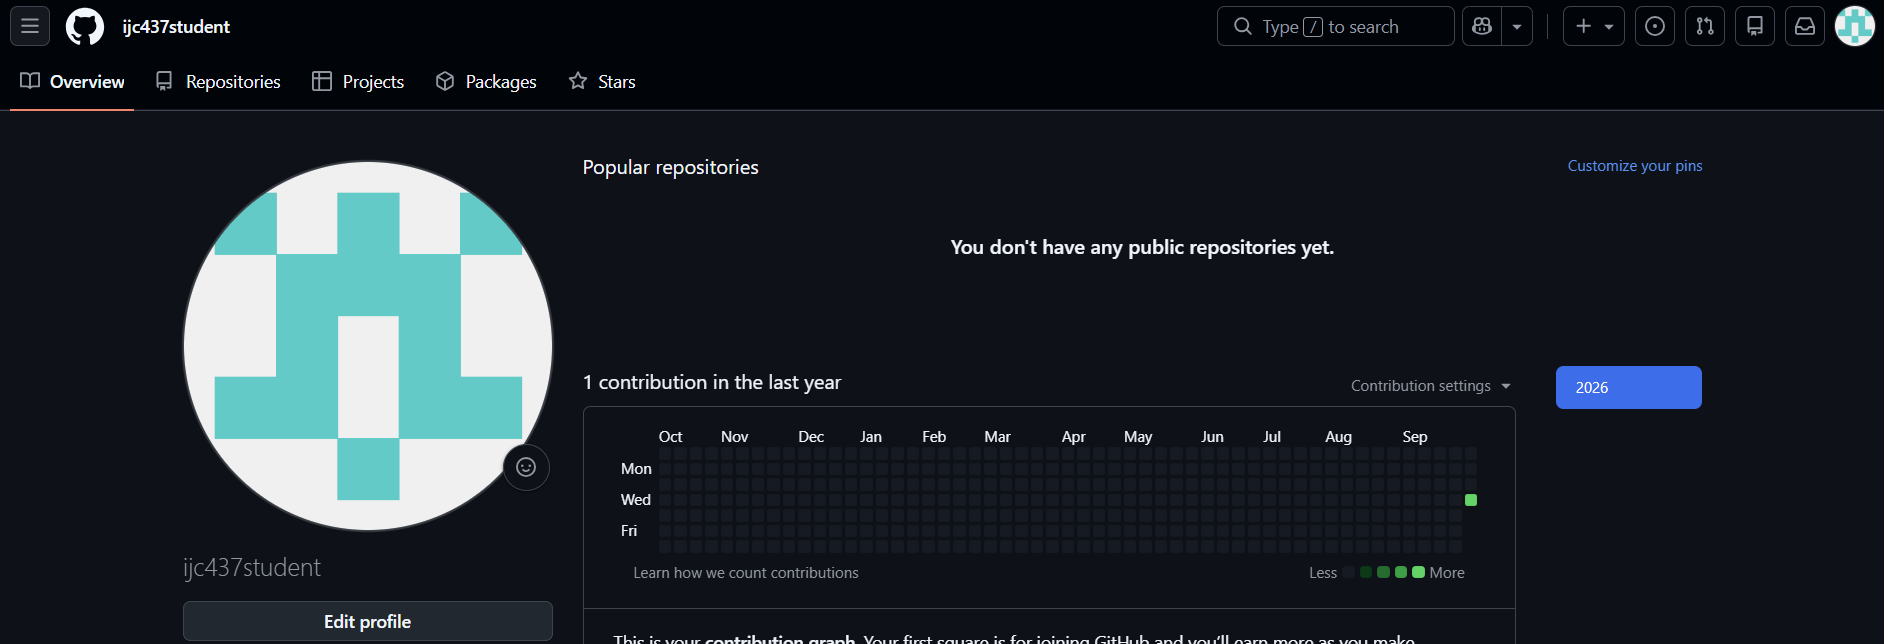

Once you select Repositories, you should be clicking on 'New' on the right hand side to create a new repository 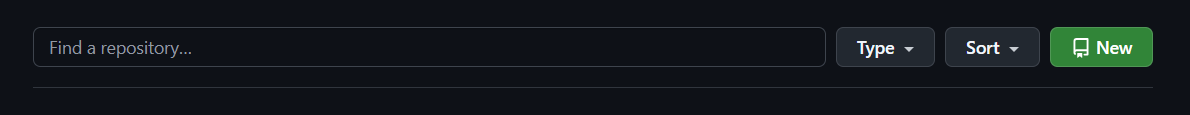

You should then provide the details about your new project, and in this, also add the README file.

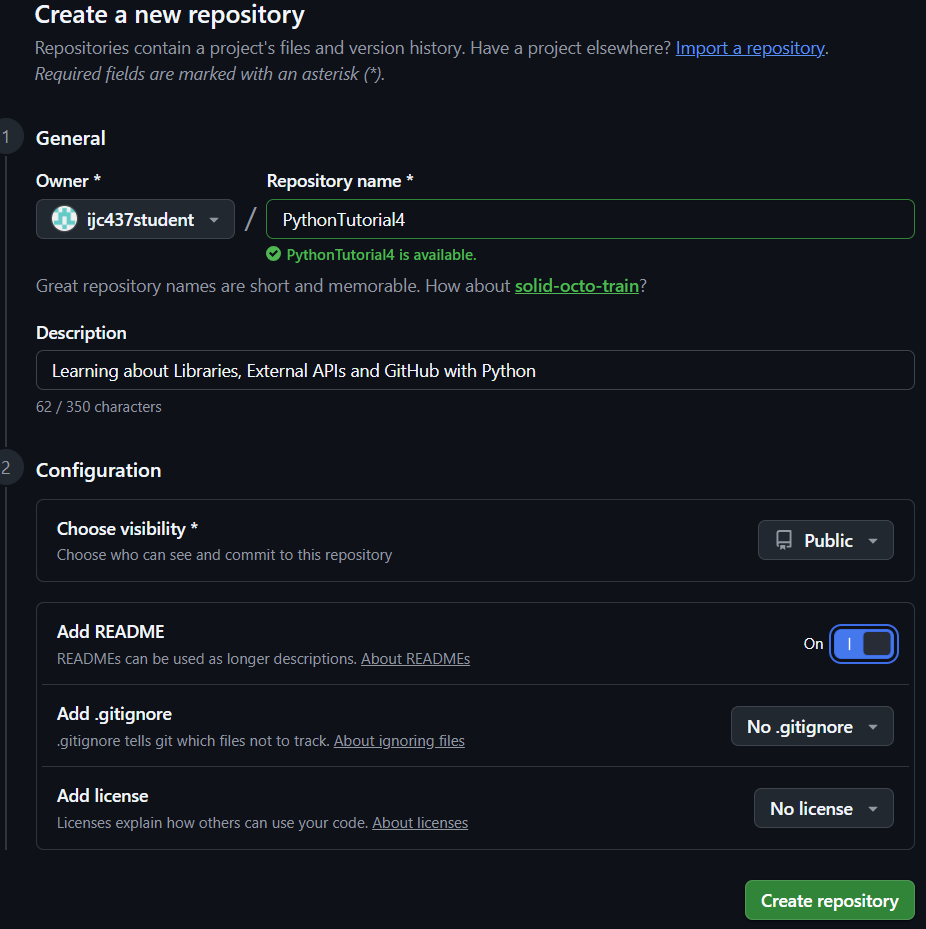

You should then 'Create repository'. Now you should have a GitHub Repository that is ready for your Colab notebook, and has a README.md file that can provide further information about your project.

Now in order to publish your Colab Notebook to GitHub, you should:
1.  Finish and clean your notebook - remove unnecessary cell outputs and texts, clean and polish your code and comments
2.  File -> Save a copy in GitHub ...
3.  Authorise GitHub Account and Select your Target Repository   
4.  Write Commit Message (e.g. "Added XX Project" - there's some very helpful resources (for example, [this one](https://medium.com/@iambonitheuri/the-art-of-writing-meaningful-git-commit-messages-a56887a4cb49) or [this one](https://gitkraken.com/learn/git/best-practices/git-commit-message) ) on good commit messages)
5.  Select the 'Include a link to Colab' checkbox readers can launch your code

Once this is published, you should automatically be directed to the GitHub profile/project page. Your project is ready for the world!
